# Notebook 1: Dataset Selection, EDA & Preprocessing

**Capstone Project — IoT Network Intrusion Detection on Imbalanced Data**

This notebook covers:
- **Task 1**: Dataset Selection & Justification
- **Task 2**: Data Understanding & Preprocessing

## Task 1: Dataset Selection & Justification

### Dataset
- **Name**: IoT Intrusion Detection Dataset
- **Source**: [Kaggle — subhajournal/iotintrusion](https://www.kaggle.com/datasets/subhajournal/iotintrusion)
- **Records**: 1,048,575 network flow records
- **Features**: 46 numerical features + 1 categorical target (`label`)

### Domain Relevance
IoT devices are increasingly deployed in smart homes, healthcare, and industrial systems. These devices are inherently vulnerable to cyber attacks due to limited computational resources, making robust intrusion detection essential. This dataset captures real-world IoT network traffic including both benign flows and multiple attack types (DDoS, DoS, reconnaissance, etc.).

### Nature & Severity of Class Imbalance
The dataset exhibits significant multi-class imbalance. Certain attack categories (e.g., DDoS flood types) contain hundreds of thousands of samples, while others (e.g., specific reconnaissance or Mirai-based attacks) have far fewer samples. This imbalance makes naive classifiers biased toward majority classes, failing to detect rare but critical attacks.

In [1]:
# Install required libraries
# !pip install kagglehub pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Task 2: Data Understanding & Preprocessing

### 2.1 Load the Dataset

In [3]:
# Download and load dataset
path = kagglehub.dataset_download("subhajournal/iotintrusion")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"Dataset Shape: {df.shape}")
print(f"Number of features: {df.shape[1] - 1}")
print(f"Number of records: {df.shape[0]:,}")
df.head()

Dataset Shape: (1048575, 47)
Number of features: 46
Number of records: 1,048,575


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,54.00,6.00,64.00,0.329807,0.329807,0.0,1,0,1,...,0.000000,54.00,83343831.92,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-RSTFINFlood
1,0.000000,57.04,6.33,64.00,4.290556,4.290556,0.0,0,0,0,...,2.822973,57.04,82926067.47,9.5,10.464666,4.010353,160.987842,0.05,141.55,DoS-TCP_Flood
2,0.000000,0.00,1.00,64.00,33.396799,33.396799,0.0,0,0,0,...,0.000000,42.00,83127993.93,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood
3,0.328175,76175.00,17.00,64.00,4642.133010,4642.133010,0.0,0,0,0,...,0.000000,50.00,83015696.38,9.5,10.000000,0.000000,0.000000,0.00,141.55,DoS-UDP_Flood
4,0.117320,101.73,6.11,65.91,6.202211,6.202211,0.0,0,1,0,...,23.113111,57.88,82972999.18,9.5,11.346876,32.716243,3016.808286,0.19,141.55,DoS-SYN_Flood


In [4]:
# Data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 47 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   flow_duration    1048575 non-null  float64
 1   Header_Length    1048575 non-null  float64
 2   Protocol Type    1048575 non-null  float64
 3   Duration         1048575 non-null  float64
 4   Rate             1048575 non-null  float64
 5   Srate            1048575 non-null  float64
 6   Drate            1048575 non-null  float64
 7   fin_flag_number  1048575 non-null  int64  
 8   syn_flag_number  1048575 non-null  int64  
 9   rst_flag_number  1048575 non-null  int64  
 10  psh_flag_number  1048575 non-null  int64  
 11  ack_flag_number  1048575 non-null  int64  
 12  ece_flag_number  1048575 non-null  int64  
 13  cwr_flag_number  1048575 non-null  int64  
 14  ack_count        1048575 non-null  float64
 15  syn_count        1048575 non-null  float64
 16  fin_count        1

In [5]:
# Descriptive statistics
df.describe()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,5.763553e+00,7.759537e+04,9.062979e+00,6.635523e+01,9.146945e+03,9.146945e+03,1.807621e-06,8.655842e-02,2.073090e-01,9.057149e-02,...,1.248502e+02,3.345817e+01,1.248978e+02,8.317382e+07,9.497998e+00,1.312711e+01,4.728151e+01,3.147998e+04,9.635824e-02,1.414999e+02
std,2.965660e+02,4.664043e+05,8.936737e+00,1.408680e+01,9.974794e+04,9.974794e+04,8.501385e-04,2.811870e-01,4.053790e-01,2.869989e-01,...,2.420296e+02,1.622552e+02,2.429223e+02,1.703857e+07,8.187710e-01,8.639921e+00,2.294819e+02,3.645895e+05,2.327718e-01,2.105725e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.200000e+01,0.000000e+00,4.200000e+01,0.000000e+00,1.000000e+00,9.165151e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,2.087155e+00,2.087155e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.000000e+01,0.000000e+00,5.000000e+01,8.307157e+07,9.500000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
50%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,1.581371e+01,1.581371e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.400000e+01,0.000000e+00,5.400000e+01,8.312452e+07,9.500000e+00,1.039230e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
75%,1.042881e-01,2.781200e+02,1.428000e+01,6.400000e+01,1.174380e+02,1.174380e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.405208e+01,3.777740e-01,5.406000e+01,8.334390e+07,9.500000e+00,1.039675e+01,5.059213e-01,1.370916e+00,8.000000e-02,1.415500e+02
max,9.943576e+04,9.815555e+06,4.700000e+01,2.550000e+02,7.340032e+06,7.340032e+06,8.484654e-01,1.000000e+00,1.000000e+00,1.000000e+00,...,8.040961e+03,1.099626e+04,1.309800e+04,1.676394e+08,1.500000e+01,1.252094e+02,1.555106e+04,1.372844e+08,1.000000e+00,2.446000e+02


### 2.2 Missing Values Analysis

In [6]:
missing = df.isnull().sum()
total_missing = missing.sum()
print(f"Total missing values: {total_missing}")

if total_missing > 0:
    print("\nColumns with missing values:")
    print(missing[missing > 0])
else:
    print("No missing values found — no imputation needed.")

Total missing values: 0
No missing values found — no imputation needed.


### 2.3 Target Variable Analysis — Class Imbalance

In [7]:
# Class distribution
class_dist = df['label'].value_counts()
print("Class Distribution:")
print(class_dist)
print(f"\nNumber of unique classes: {df['label'].nunique()}")
print(f"\nImbalance ratio (max/min): {class_dist.max() / class_dist.min():.2f}")

Class Distribution:
label
DDoS-ICMP_Flood            161281
DDoS-UDP_Flood             121205
DDoS-TCP_Flood             101293
DDoS-PSHACK_Flood           92395
DDoS-SYN_Flood              91644
DDoS-RSTFINFlood            90823
DDoS-SynonymousIP_Flood     80680
DoS-UDP_Flood               74787
DoS-TCP_Flood               59807
DoS-SYN_Flood               45207
BenignTraffic               24476
Mirai-greeth_flood          22115
Mirai-udpplain              20166
Mirai-greip_flood           16952
DDoS-ICMP_Fragmentation     10223
MITM-ArpSpoofing             7019
DDoS-ACK_Fragmentation       6431
DDoS-UDP_Fragmentation       6431
DNS_Spoofing                 4034
Recon-HostDiscovery          3007
Recon-OSScan                 2225
Recon-PortScan               1863
DoS-HTTP_Flood               1680
VulnerabilityScan             809
DDoS-HTTP_Flood               626
DDoS-SlowLoris                493
DictionaryBruteForce          324
BrowserHijacking              140
SqlInjection          

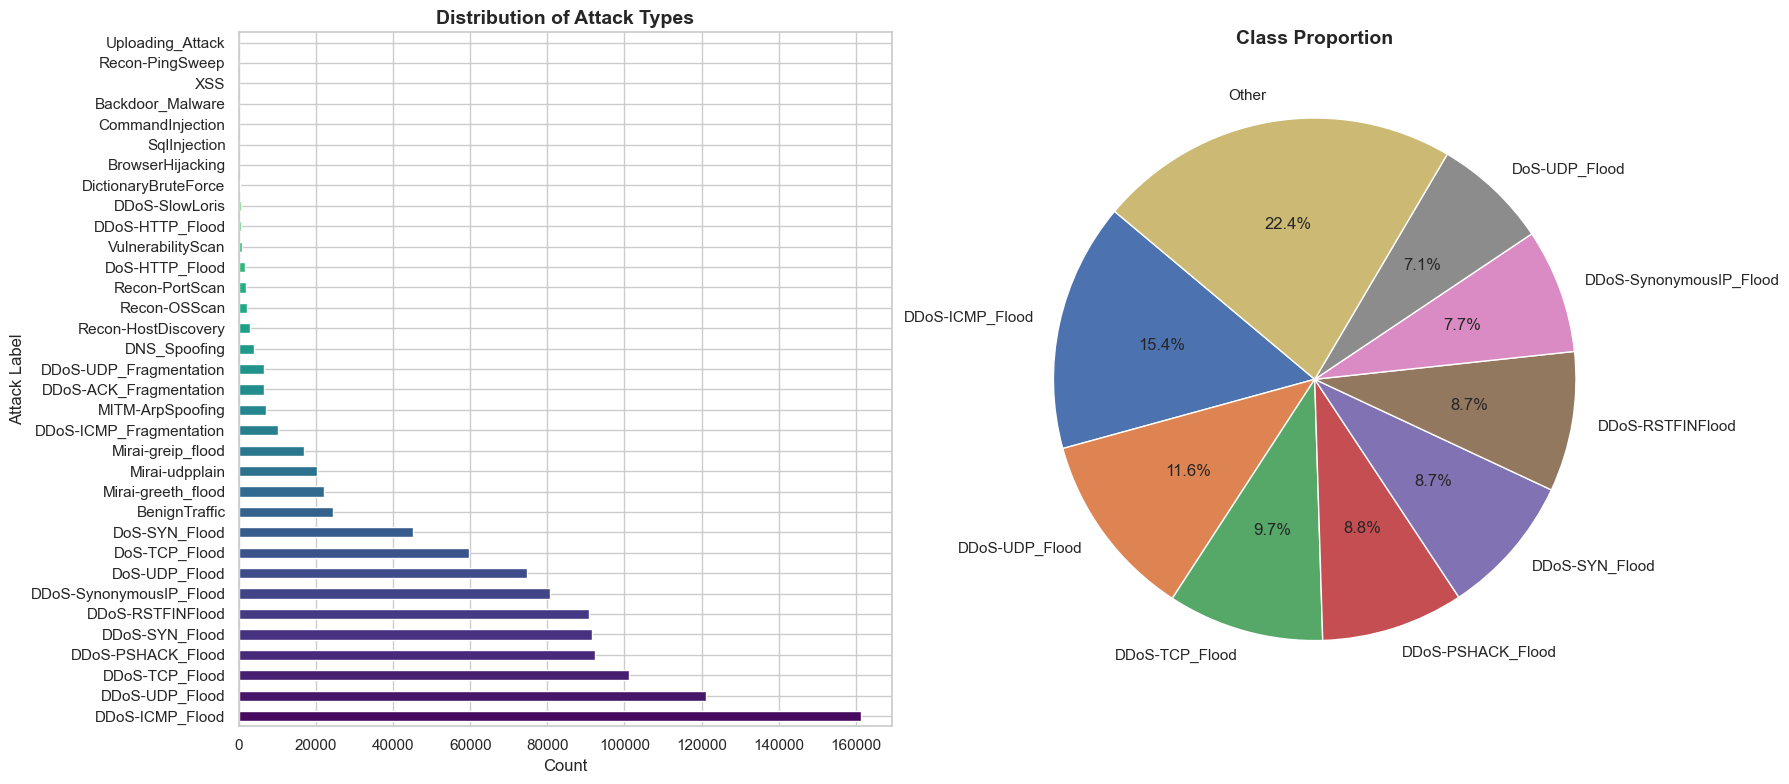

In [8]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart
ax1 = axes[0]
class_dist.plot(kind='barh', ax=ax1, color=sns.color_palette('viridis', len(class_dist)))
ax1.set_title('Distribution of Attack Types', fontsize=14, fontweight='bold')
ax1.set_xlabel('Count')
ax1.set_ylabel('Attack Label')

# Pie chart for proportions
ax2 = axes[1]
top_classes = class_dist.head(8)
other = class_dist.iloc[8:].sum() if len(class_dist) > 8 else 0
if other > 0:
    pie_data = pd.concat([top_classes, pd.Series({'Other': other})])
else:
    pie_data = top_classes
pie_data.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=140)
ax2.set_title('Class Proportion', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Feature Distributions

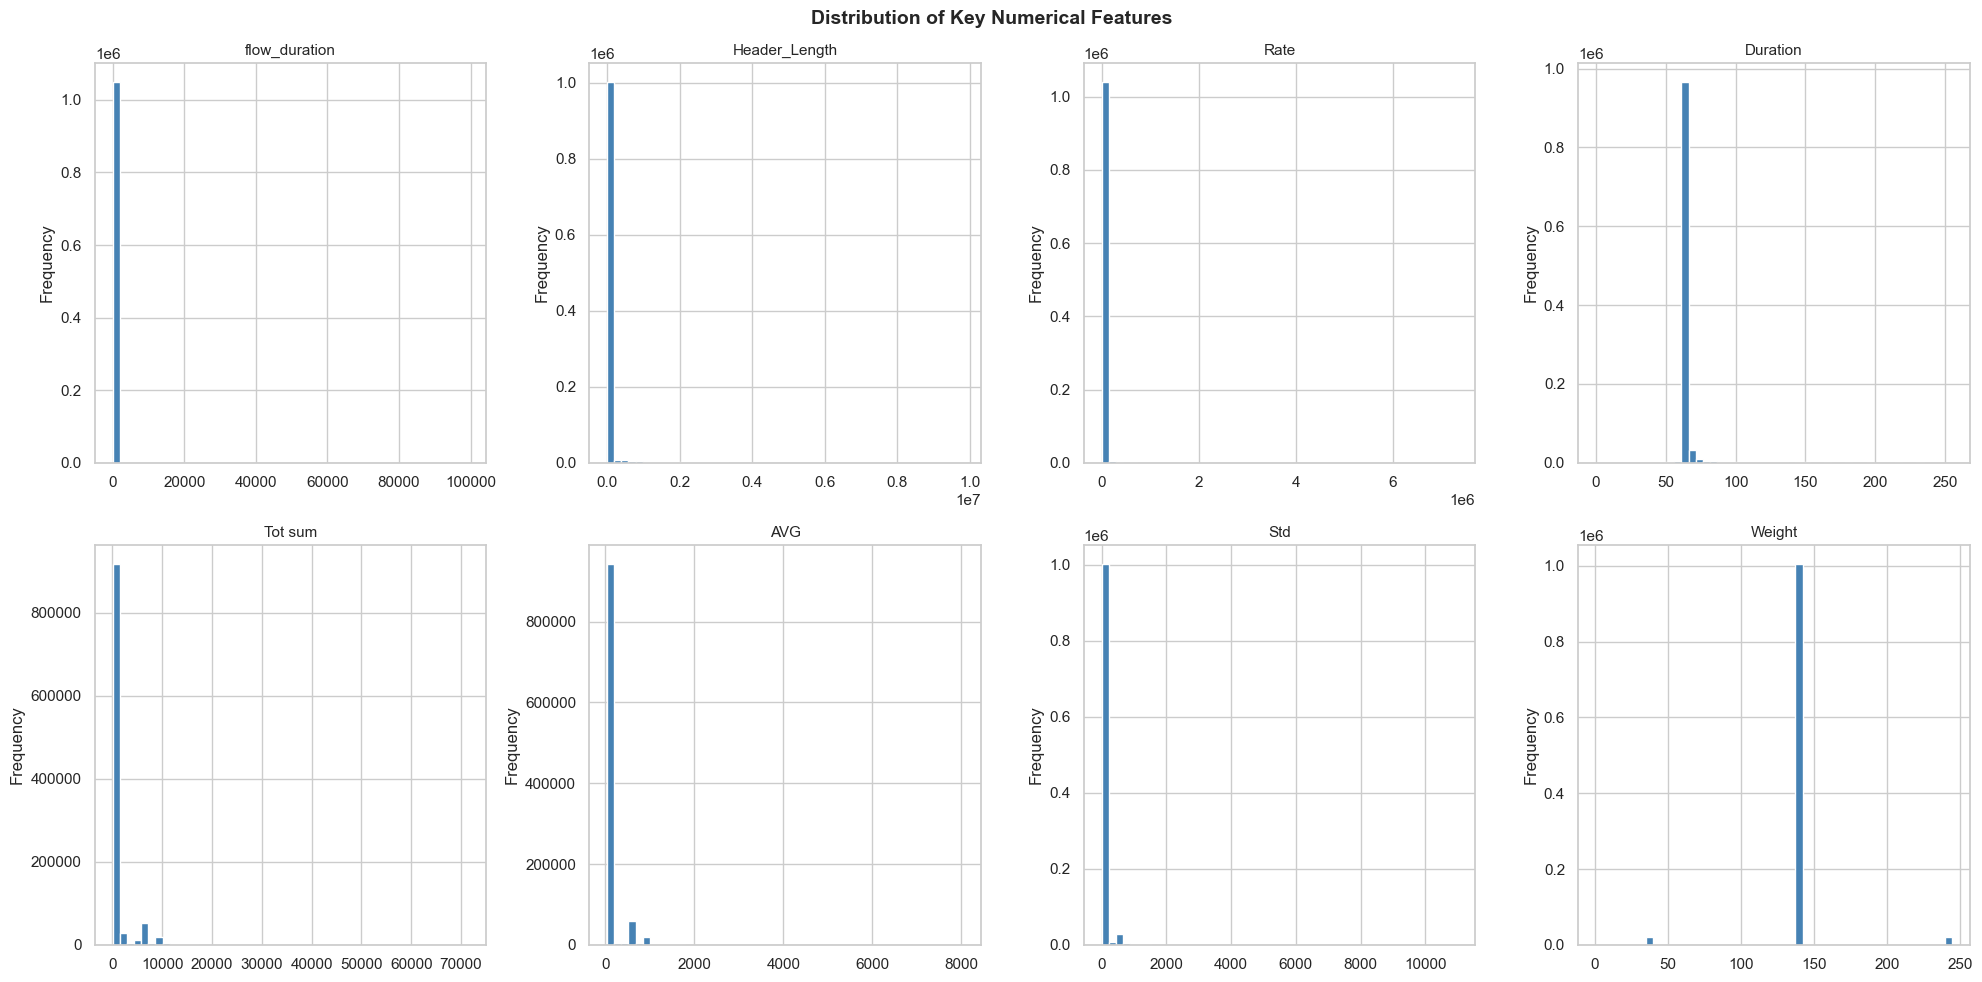

In [9]:
# Distribution of key continuous features
key_features = ['flow_duration', 'Header_Length', 'Rate', 'Duration', 'Tot sum', 'AVG', 'Std', 'Weight']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, feat in enumerate(key_features):
    ax = axes[i // 4][i % 4]
    df[feat].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(feat, fontsize=11)
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Key Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Correlation Analysis

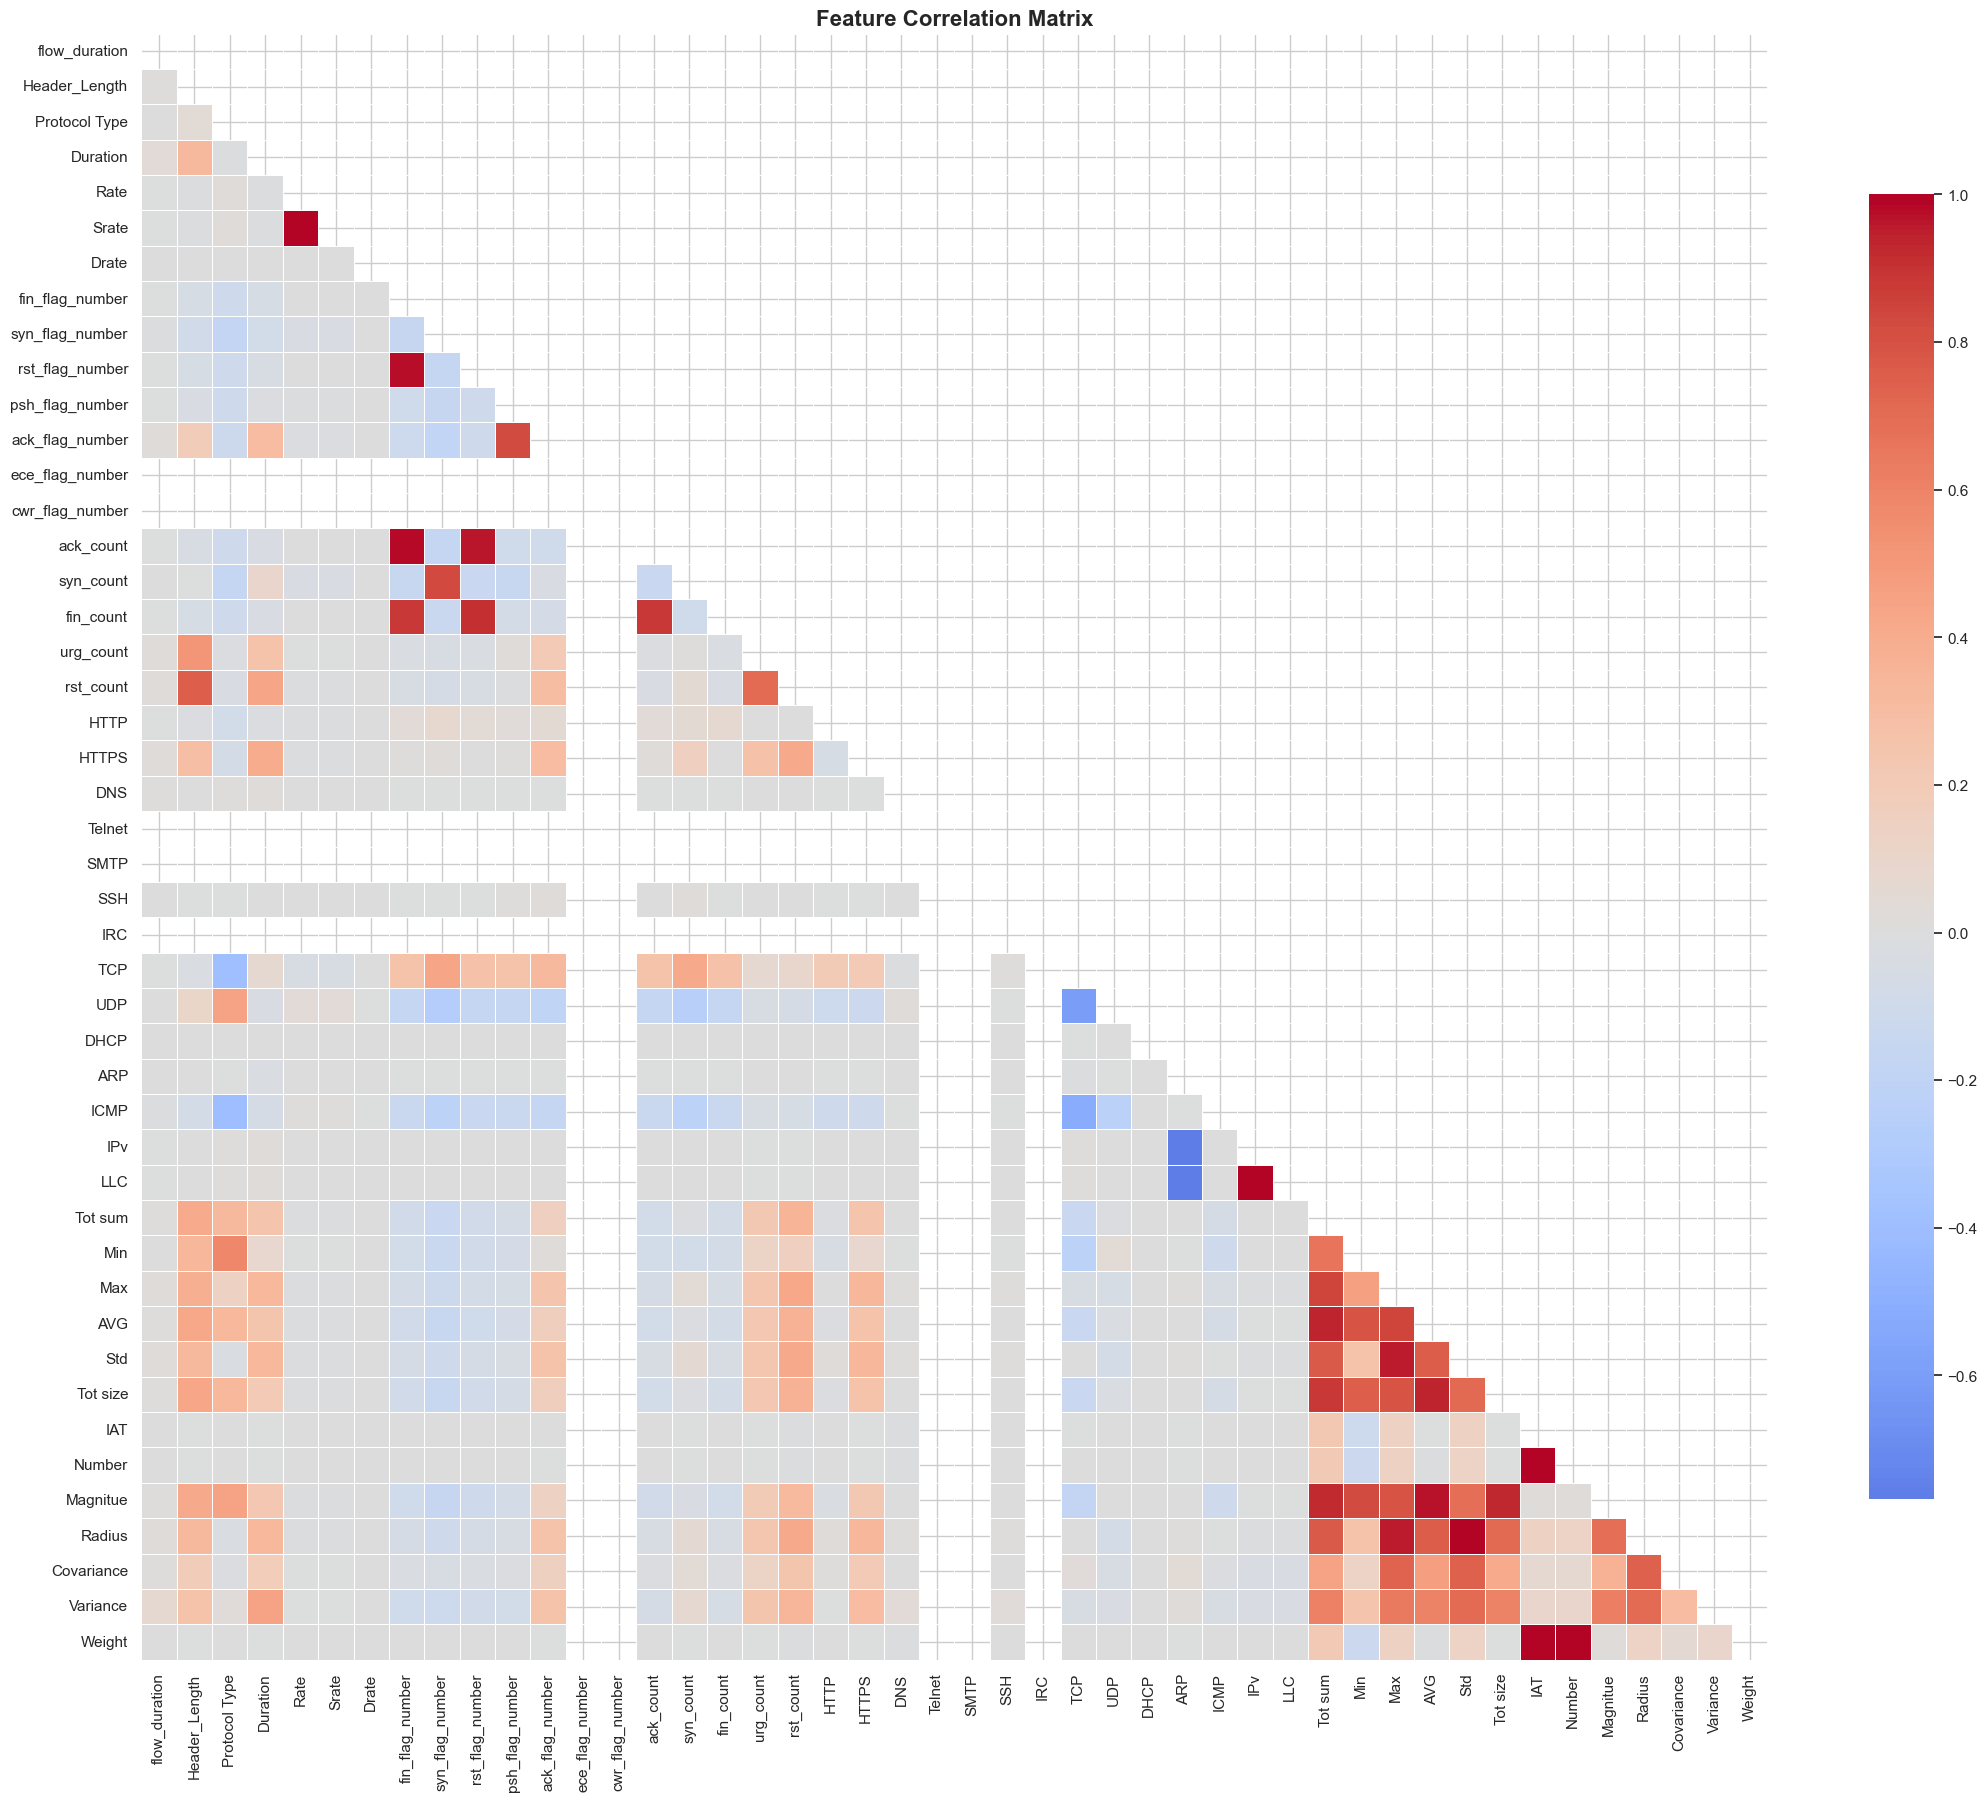

In [10]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(22, 18))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot=False,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Identify highly correlated feature pairs (|r| > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
print(f"Number of highly correlated pairs (|r| > 0.9): {len(high_corr_df)}")
high_corr_df

Number of highly correlated pairs (|r| > 0.9): 17


,Feature 1,Feature 2,Correlation
0,Rate,Srate,1.000
1,fin_flag_number,rst_flag_number,0.975
2,fin_flag_number,ack_count,0.986
3,rst_flag_number,ack_count,0.962
4,rst_flag_number,fin_count,0.905
5,IPv,LLC,1.000
6,Tot sum,AVG,0.933
7,Tot sum,Magnitue,0.923
8,Max,Std,0.953
9,Max,Radius,0.953


### 2.6 Outlier Detection

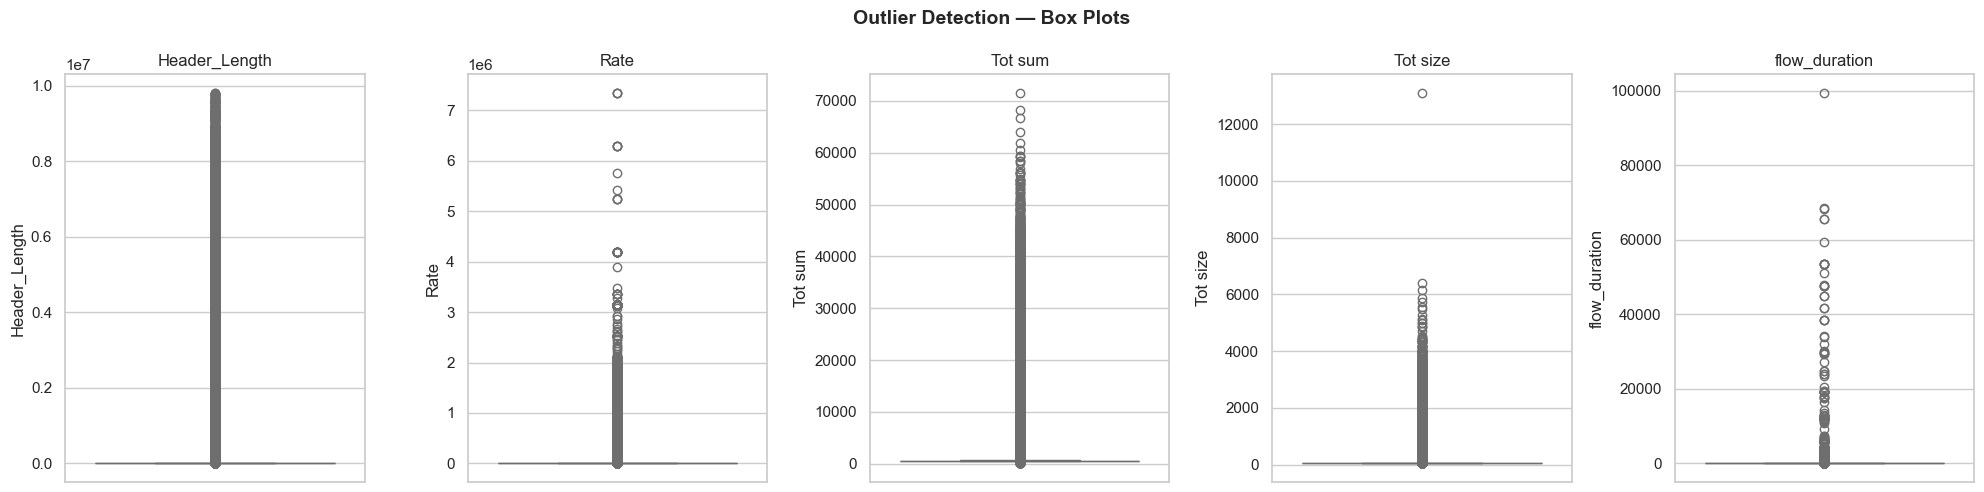

In [12]:
# Box plots for continuous features to visualize outliers
outlier_features = ['Header_Length', 'Rate', 'Tot sum', 'Tot size', 'flow_duration']

fig, axes = plt.subplots(1, len(outlier_features), figsize=(20, 5))
for i, feat in enumerate(outlier_features):
    sns.boxplot(y=df[feat], ax=axes[i], color='lightcoral')
    axes[i].set_title(feat)

plt.suptitle('Outlier Detection — Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Winsorization: cap outliers at 1st and 99th percentiles
from scipy.stats import mstats

continuous_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in continuous_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers capped at 1st/99th percentiles (Winsorization applied).")

Outliers capped at 1st/99th percentiles (Winsorization applied).


### 2.7 Label Encoding & Feature Scaling

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode target variable
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Print mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Encoding Mapping:")
for name, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"  {code}: {name}")

Label Encoding Mapping:
  0: Backdoor_Malware
  1: BenignTraffic
  2: BrowserHijacking
  3: CommandInjection
  4: DDoS-ACK_Fragmentation
  5: DDoS-HTTP_Flood
  6: DDoS-ICMP_Flood
  7: DDoS-ICMP_Fragmentation
  8: DDoS-PSHACK_Flood
  9: DDoS-RSTFINFlood
  10: DDoS-SYN_Flood
  11: DDoS-SlowLoris
  12: DDoS-SynonymousIP_Flood
  13: DDoS-TCP_Flood
  14: DDoS-UDP_Flood
  15: DDoS-UDP_Fragmentation
  16: DNS_Spoofing
  17: DictionaryBruteForce
  18: DoS-HTTP_Flood
  19: DoS-SYN_Flood
  20: DoS-TCP_Flood
  21: DoS-UDP_Flood
  22: MITM-ArpSpoofing
  23: Mirai-greeth_flood
  24: Mirai-greip_flood
  25: Mirai-udpplain
  26: Recon-HostDiscovery
  27: Recon-OSScan
  28: Recon-PingSweep
  29: Recon-PortScan
  30: SqlInjection
  31: Uploading_Attack
  32: VulnerabilityScan
  33: XSS


In [15]:
# Separate features and target
X = df.drop(['label', 'label_encoded'], axis=1)
y = df['label_encoded']

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Features shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")
X_scaled.head()

Features shape: (1048575, 46)
Target shape: (1048575,)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
0,-0.221971,-0.202394,-0.342745,-0.197789,-0.244603,-0.244603,0.0,3.248521,-0.511396,3.168754,...,-0.324196,-0.239981,-0.323405,0.010076,0.002062,-0.324472,-0.239864,-0.209170,-0.413960,0.002228
1,-0.221971,-0.202384,-0.305819,-0.197789,-0.244343,-0.244343,0.0,-0.307832,-0.511396,-0.315581,...,-0.320196,-0.216388,-0.308149,-0.014454,0.002062,-0.315519,-0.216149,-0.207327,-0.199158,0.002228
2,-0.221971,-0.202573,-0.902236,-0.197789,-0.242427,-0.242427,0.0,-0.307832,-0.511396,-0.315581,...,-0.384465,-0.239981,-0.383626,-0.002597,0.002062,-0.476307,-0.239864,-0.209170,-0.413960,0.002228
3,-0.180158,0.050812,0.888134,-0.197789,0.060817,0.060817,0.0,-0.307832,-0.511396,-0.315581,...,-0.344286,-0.239981,-0.343479,-0.009191,0.002062,-0.373011,-0.239864,-0.209170,-0.413960,0.002228
4,-0.207023,-0.202235,-0.330436,-0.002591,-0.244217,-0.244217,0.0,-0.307832,1.955433,-0.315581,...,-0.254087,-0.046814,-0.303934,-0.011698,0.002062,-0.206363,-0.046395,-0.174637,0.402290,0.002228


### 2.8 Save Processed Data

In [ ]:
# Save processed data for subsequent notebooks
processed_df = X_scaled.copy()
processed_df['label'] = df['label'].values
processed_df['label_encoded'] = y.values

processed_df.to_csv('processed_iot_intrusion.csv', index=False)
print("Processed data saved to 'processed_iot_intrusion.csv'")
print(f"Final shape: {processed_df.shape}")

---
### Summary of EDA & Preprocessing
- **No missing values** found.
- **Significant class imbalance** across multiple attack types.
- **Outliers** handled via Winsorization at 1st/99th percentiles.
- **Features scaled** using StandardScaler.
- **Labels encoded** to integers.
- Data saved for use in Notebooks 2, 3, and 4.